PHASE ONE - Setting up the Environmet
importing all necessary library

In [63]:
# Install and import All required Libraries

# --- Safe Installation Method for Windows ---
import sys
import subprocess

packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'xgboost',
    'imbalanced-learn',
    'openpyxl'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '--quiet'])

print("All Packages installed")
#import core libraries
import pandas as pd
import numpy as np

#visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

#machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

#display setting
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format','{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10,5)

print("All libraries loaded successfully")

All Packages installed
All libraries loaded successfully


In [64]:
#Loading the dataset
Churn_df = pd.read_excel('C:/Users/HP/Desktop/Datafrik_AI_ML_Assignments_Project/ASS_2-Supervised_Learning_Customer_Churn/Customer Churn Dataset.xlsx')

print(f"Dataset Loaded! Shape: {Churn_df.shape}")

Dataset Loaded! Shape: (7043, 21)


In [65]:
#preview the data - checking the first 10 rows
Churn_df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [66]:
#Inspecting the Data structure
Churn_df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  \
0              No  No phone service             DSL      

PHASE 2 - CLEANED AND ENCODED DATA


In [67]:
# Fix 1: Convert SeniorCitizen from 0/1 to Yes/No, i.e, from integer to object
Churn_df['SeniorCitizen'] = Churn_df['SeniorCitizen'].map({0: 'No', 1:'Yes'})

Churn_df['SeniorCitizen'].unique()

array(['No', 'Yes'], dtype=object)

In [68]:
# Fix 2: Checking for Missing Values and Fix
# There are eleven (11) missing values in Total charges. 
Churn_df.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [69]:
# Investigating Missing values in TotalCharges
# Show rows where TotalCharge is missing
# Findings - There are six (6) males and five (5) female missing Total charges. Moreover, they total charges 
# might be missing due to zero tenure

Churn_df[Churn_df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [70]:
# Handling Missing Values
# Replace all missing values with 0

Churn_df["TotalCharges"] = Churn_df["TotalCharges"].fillna(0)

# Verify
Churn_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [71]:
# Checking unique values in every column

cat_cols = Churn_df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    print(f"{col:20s} > {Churn_df[col].unique().tolist()}")
    print()

customerID           > ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU', '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU', '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS', '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB', '8779-QRDMV', '1680-VDCWW', '1066-JKSGK', '3638-WEABW', '6322-HRPFA', '6865-JZNKO', '6467-CHFZW', '8665-UTDHZ', '5248-YGIJN', '8773-HHUOZ', '3841-NFECX', '4929-XIHVW', '6827-IEAUQ', '7310-EGVHZ', '3413-BMNZE', '6234-RAAPL', '6047-YHPVI', '6572-ADKRS', '5380-WJKOV', '8168-UQWWF', '8865-TNMNX', '9489-DEDVP', '9867-JCZSP', '4671-VJLCL', '4080-IIARD', '3714-NTNFO', '5948-UJZLF', '7760-OYPDY', '7639-LIAYI', '2954-PIBKO', '8012-SOUDQ', '9420-LOJKX', '6575-SUVOI', '7495-OOKFY', '4667-QONEA', '1658-BYGOY', '8769-KKTPH', '5067-XJQFU', '3957-SQXML', '5954-BDFSG', '0434-CSFON', '1215-FIGMP', '0526-SXDJP', '0557-ASKVU', '5698-BQJOH', '5122-CYFXA', '8627-ZYGSZ', '3410-YOQBQ', '3170-NMYVV', '7410-OIED

DROP UNNECESSARY COLUMNS AND ENCODE CATEGORIES

In [72]:
Churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [73]:
# Drop Customer ID & Encode All Categorical Columns - Customer ID is a unique id.

# Step 1: Drop Customer ID
Churn_df = Churn_df.drop(columns=['customerID'])

# Step 2: Columns where "No internet service" = "No"

no_internet_columns = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

for col in no_internet_columns:
    Churn_df[col] = Churn_df[col].replace({'No internet service': 'No',
                               'No phone service': 'No'})


# Step 3: Binary columns > Yes=1, No=0
binary_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

binary_map = {'Yes':1, 'No':0, 'Male':1, 'Female':0}
for col in binary_cols:
    Churn_df[col] = Churn_df[col].map(binary_map)

# Step 4: One-hot encoding for multi-category columns
Churn_df = pd.get_dummies(Churn_df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=False)

# Step 6: Encode target variable
Churn_df['Churn'] = Churn_df['Churn'].map({'Yes':1, 'No':0})

# Verify
print(f"Encoding complete! New Shape: {Churn_df.shape}")
print(f"\nChurn Value counts:\n{Churn_df['Churn'].value_counts()}")
print(f"\nSample of new columns: {Churn_df.columns.tolist()}")

Encoding complete! New Shape: (7043, 27)

Churn Value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Sample of new columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [74]:
#cross checking for the sum of missing value 
Churn_df.head(10)
Churn_df.isnull().sum()

gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
MultipleLines                              0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                                0
StreamingTV                                0
StreamingMovies                            0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
InternetService_DSL                        0
InternetService_Fiber optic                0
InternetService_No                         0
Contract_Month-to-month                    0
Contract_One year                          0
Contract_T

SUMMARY STATISTICS

In [75]:
Churn_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False,True,False,False,False,False,True,False


In [76]:
Churn_df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,7043.00,0.50,0.50,0.00,0.00,1.00,1.00,1.00
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043.00,0.48,0.50,0.00,0.00,0.00,1.00,1.00
Dependents,7043.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043.00,0.90,0.30,0.00,1.00,1.00,1.00,1.00
MultipleLines,7043.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
OnlineSecurity,7043.00,0.29,0.45,0.00,0.00,0.00,1.00,1.00
OnlineBackup,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00
DeviceProtection,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00


PHASE 3 - EXPLORATORY DATA ANALYSIS
Univariate, Bivariate and Multivariate Analysis

Stayed: 5,174 (73.5%)
Churned: 1,869 (26.5%)


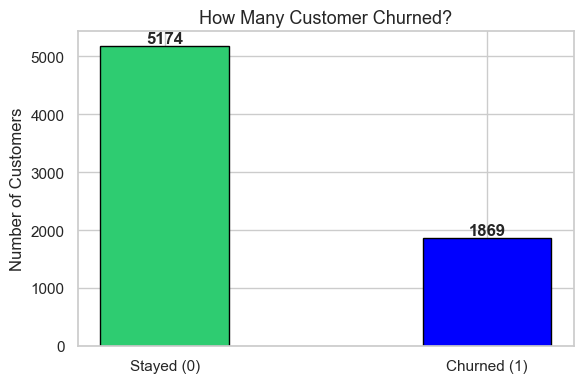

In [77]:
# Churn Distribution
# How many customers churned Vs stayed

churn_counts = Churn_df['Churn'].value_counts()

plt.figure(figsize = (6, 4))
plt.bar(['Stayed (0)', 'Churned (1)'], 
        churn_counts.values,
        color=['#2ecc71', 'blue'],
        edgecolor='black', width=0.4)

# Add the numbers on top of each bar
for i, v in enumerate(churn_counts.values):
    plt.text(i, v+50, str(v), ha='center', fontweight='bold')
    plt.title('How Many Customer Churned?', fontsize=13)
    plt.ylabel('Number of Customers')
    plt.tight_layout()
    plt.show

print (f"Stayed: {churn_counts[0]:,} ({churn_counts[0]/len(Churn_df)*100:.1f}%)")
print (f"Churned: {churn_counts[1]:,} ({churn_counts[1]/len(Churn_df)*100:.1f}%)")

## Findings - About 1869 customers were churned while 5174 customers stayed.

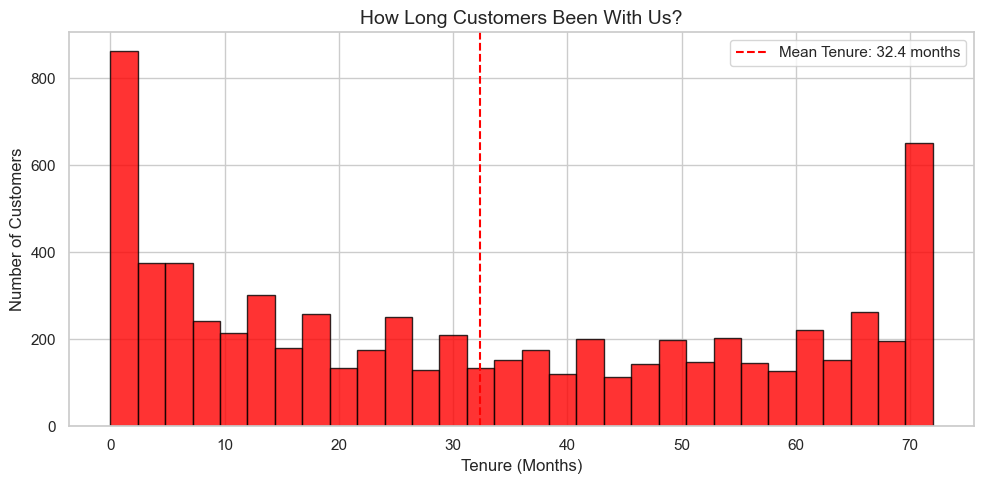

In [78]:
# Distribution of Tenure
plt.Figure(figsize=(8, 5))
plt.hist(Churn_df['tenure'], bins=30, color='red', edgecolor='black', alpha=0.8)
plt.axvline(Churn_df['tenure'].mean(), color='red', linestyle='--', label=f"Mean Tenure: {Churn_df['tenure'].mean():.1f} months")
plt.title ('How Long Customers Been With Us?', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

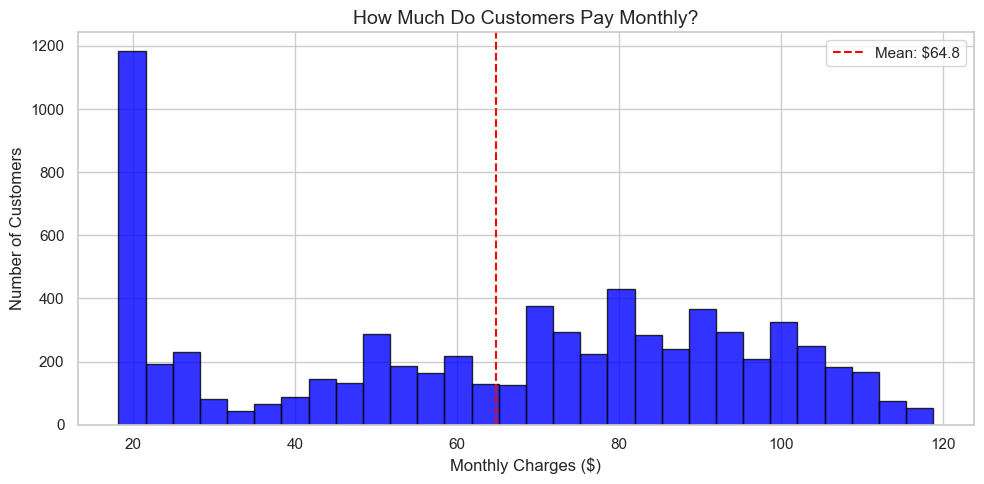

In [79]:
# Distribution of Monthly Charge

# Distribution of Tenure
plt.Figure(figsize=(8, 5))
plt.hist(Churn_df['MonthlyCharges'], bins=30, color='blue', edgecolor='black', alpha=0.8)
plt.axvline(Churn_df['MonthlyCharges'].mean(), color='red', linestyle='--', label=f"Mean: ${Churn_df['MonthlyCharges'].mean():.1f}")
plt.title ('How Much Do Customers Pay Monthly?', fontsize=14)
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

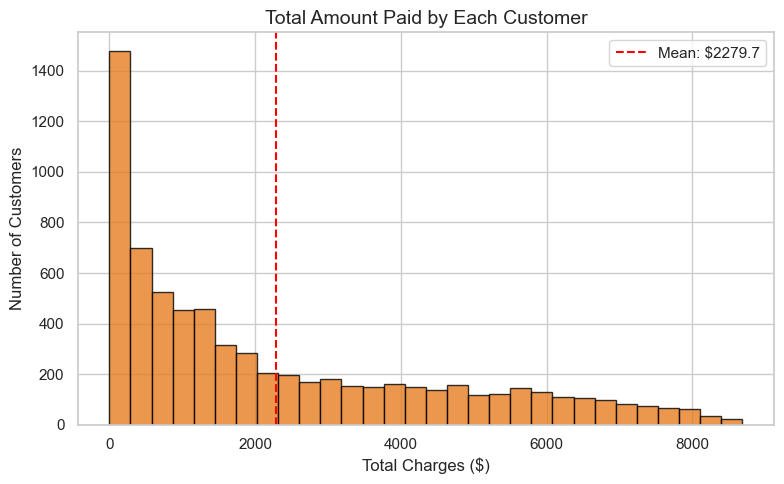

Lowest total  : $0.0
Average total : $2279.73
Highest total : $8684.8


In [80]:
# Distribution of Total Charges

plt.figure(figsize=(8, 5))
plt.hist(Churn_df['TotalCharges'], bins=30,
         color='#e67e22', edgecolor='black', alpha=0.8)

plt.axvline(Churn_df['TotalCharges'].mean(), color='red',
            linestyle='--',
            label=f"Mean: ${Churn_df['TotalCharges'].mean():.1f}")

plt.title('Total Amount Paid by Each Customer', fontsize=14)
plt.xlabel('Total Charges ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Lowest total  : ${Churn_df['TotalCharges'].min()}")
print(f"Average total : ${Churn_df['TotalCharges'].mean():.2f}")
print(f"Highest total : ${Churn_df['TotalCharges'].max()}")

BIVARIATE ANALYSIS

<Figure size 700x500 with 0 Axes>

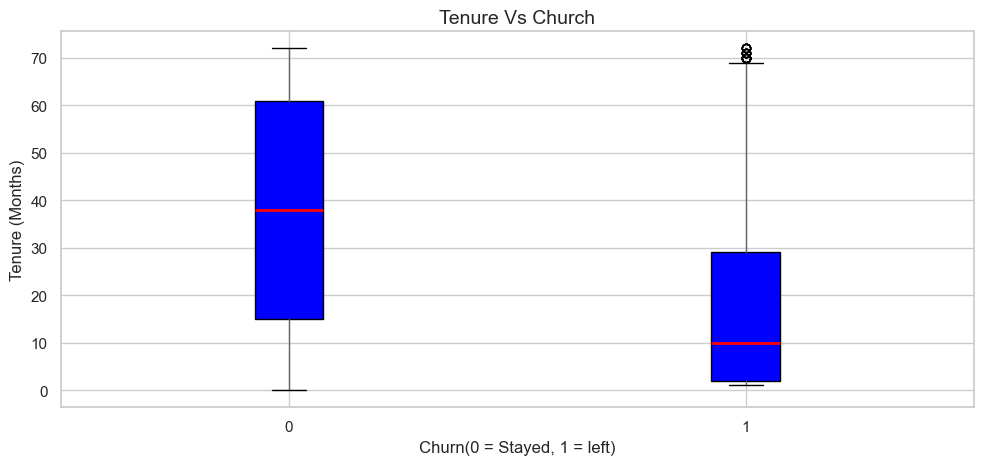

Average tenure by Churn status:
Churn
0   37.60
1   18.00
Name: tenure, dtype: float64


In [81]:
#Do churners leave early?
#'How long do churners stay before they leave'

plt.figure(figsize=(7,5))
Churn_df.boxplot(column= 'tenure', by='Churn', patch_artist = True,
           boxprops=dict(facecolor='blue', color='black'),
           medianprops=dict(color='red', linewidth=2))

plt.title('Tenure Vs Church', fontsize=14)
plt.suptitle('')
plt.xlabel('Churn(0 = Stayed, 1 = left)')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()

#print average tenure for each group
print("Average tenure by Churn status:")
print(Churn_df.groupby('Churn')['tenure'].mean().round(1))

<Figure size 700x500 with 0 Axes>

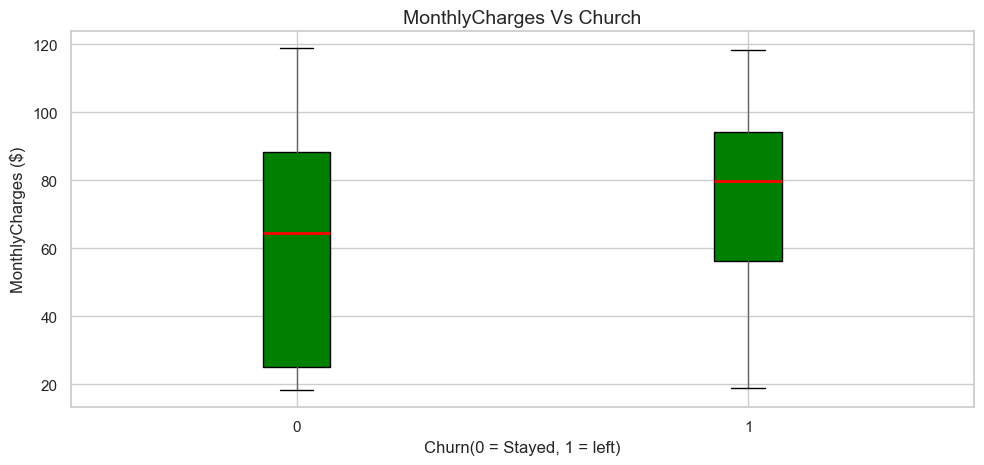

Average Monthly Charge by Churn status:
Churn
0   61.27
1   74.44
Name: MonthlyCharges, dtype: float64


In [82]:
# Monthly Charges Vs Churn
# "Do Customers who pay more churn more?"

plt.figure(figsize=(7,5))
Churn_df.boxplot(column= 'MonthlyCharges', by='Churn', patch_artist = True,
           boxprops=dict(facecolor='green', color='black'),
           medianprops=dict(color='red', linewidth=2))

plt.title('MonthlyCharges Vs Church', fontsize=14)
plt.suptitle('')
plt.xlabel('Churn(0 = Stayed, 1 = left)')
plt.ylabel('MonthlyCharges ($)')
plt.tight_layout()
plt.show()

#print average tenure for each group
print("Average Monthly Charge by Churn status:")
print(Churn_df.groupby('Churn')['MonthlyCharges'].mean().round(2))

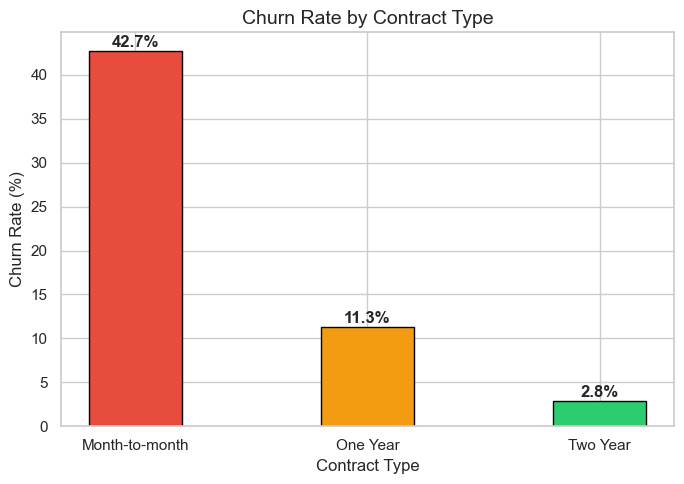

Churn Rate by Contract Type:
Contract_Type
Month-to-month   42.70
One Year         11.30
Two Year          2.80
Name: Churn, dtype: float64


In [83]:
# Contract Type Vs Churn

# Calculate churn rate per contract type
contract_churn = Churn_df.groupby([
    'Contract_Month-to-month',
    'Contract_One year',
    'Contract_Two year'
])['Churn'].mean() * 100


# Simpler approach — rebuild contract column for plotting
Churn_df['Contract_Type'] = 'Month-to-month'
Churn_df.loc[Churn_df['Contract_One year'] == 1, 'Contract_Type'] = 'One Year'
Churn_df.loc[Churn_df['Contract_Two year'] == 1, 'Contract_Type'] = 'Two Year'

churn_by_contract = Churn_df.groupby('Contract_Type')['Churn'].mean() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_contract.index,
               churn_by_contract.values,
               color=['#e74c3c', '#f39c12', '#2ecc71'],
               edgecolor='black', width=0.4)

# Add percentage labels on bars
for bar, val in zip(bars, churn_by_contract.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Contract Type:")
print(churn_by_contract.round(1))

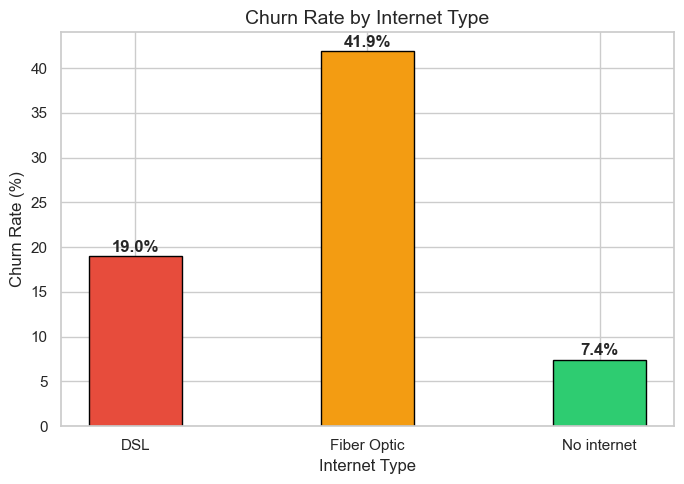

Churn Rate by Internet Type:
Internet_Type
DSL           19.00
Fiber Optic   41.90
No internet    7.40
Name: Churn, dtype: float64


In [84]:
# internet services vs churn
# rebuild internet service columns for plotting
Churn_df['Internet_Type'] = 'No internet'
Churn_df.loc[Churn_df['InternetService_DSL'] == 1, 'Internet_Type'] = 'DSL'
Churn_df.loc[Churn_df['InternetService_Fiber optic'] == 1, 'Internet_Type'] = 'Fiber Optic'

churn_by_internet = Churn_df.groupby('Internet_Type')['Churn'].mean() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_internet.index,
               churn_by_internet.values,
               color=['#e74c3c', '#f39c12', '#2ecc71'],
               edgecolor='black', width=0.4)

# Add percentage labels on bars
for bar, val in zip(bars, churn_by_internet.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Internet Type', fontsize=14)
plt.xlabel('Internet Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Internet Type:")
print(churn_by_internet.round(1))

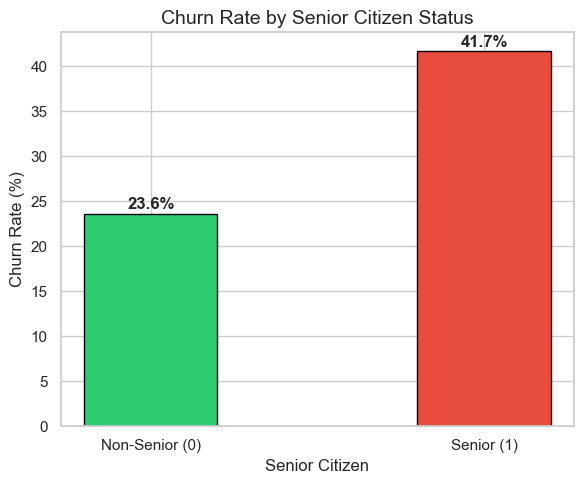

Churn Rate by Senior Citizen Status:
SeniorCitizen
0   23.60
1   41.70
Name: Churn, dtype: float64

Customer Count by Senior Citizen Status:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


In [85]:
# Senior Citizen vs Churn

churn_by_senior = Churn_df.groupby('SeniorCitizen')['Churn'].mean() * 100

plt.figure(figsize=(6, 5))
bars = plt.bar(['Non-Senior (0)', 'Senior (1)'],
               churn_by_senior.values,
               color=['#2ecc71', '#e74c3c'],
               edgecolor='black', width=0.4)

for bar, val in zip(bars, churn_by_senior.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Senior Citizen Status', fontsize=14)
plt.xlabel('Senior Citizen')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Senior Citizen Status:")
print(churn_by_senior.round(1))

print("\nCustomer Count by Senior Citizen Status:")
print(Churn_df['SeniorCitizen'].value_counts())

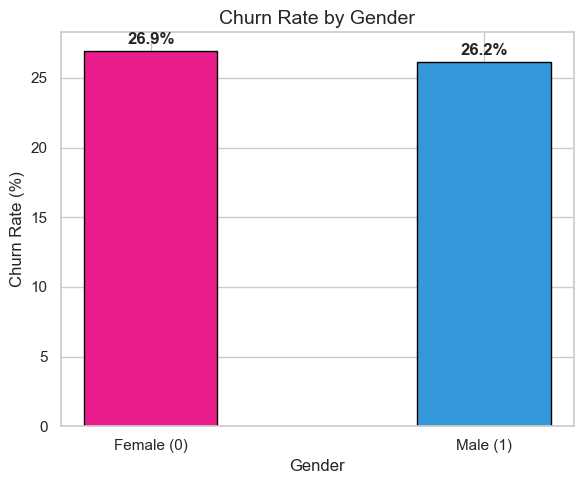

Churn Rate by Gender:
gender
0   26.90
1   26.20
Name: Churn, dtype: float64


In [86]:
# Gender vs Churn

churn_by_gender = Churn_df.groupby('gender')['Churn'].mean() * 100

plt.figure(figsize=(6, 5))
bars = plt.bar(['Female (0)', 'Male (1)'],
               churn_by_gender.values,
               color=['#e91e8c', '#3498db'],
               edgecolor='black', width=0.4)

for bar, val in zip(bars, churn_by_gender.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Gender:")
print(churn_by_gender.round(1))

MULTIVARIATE ANALYSIS

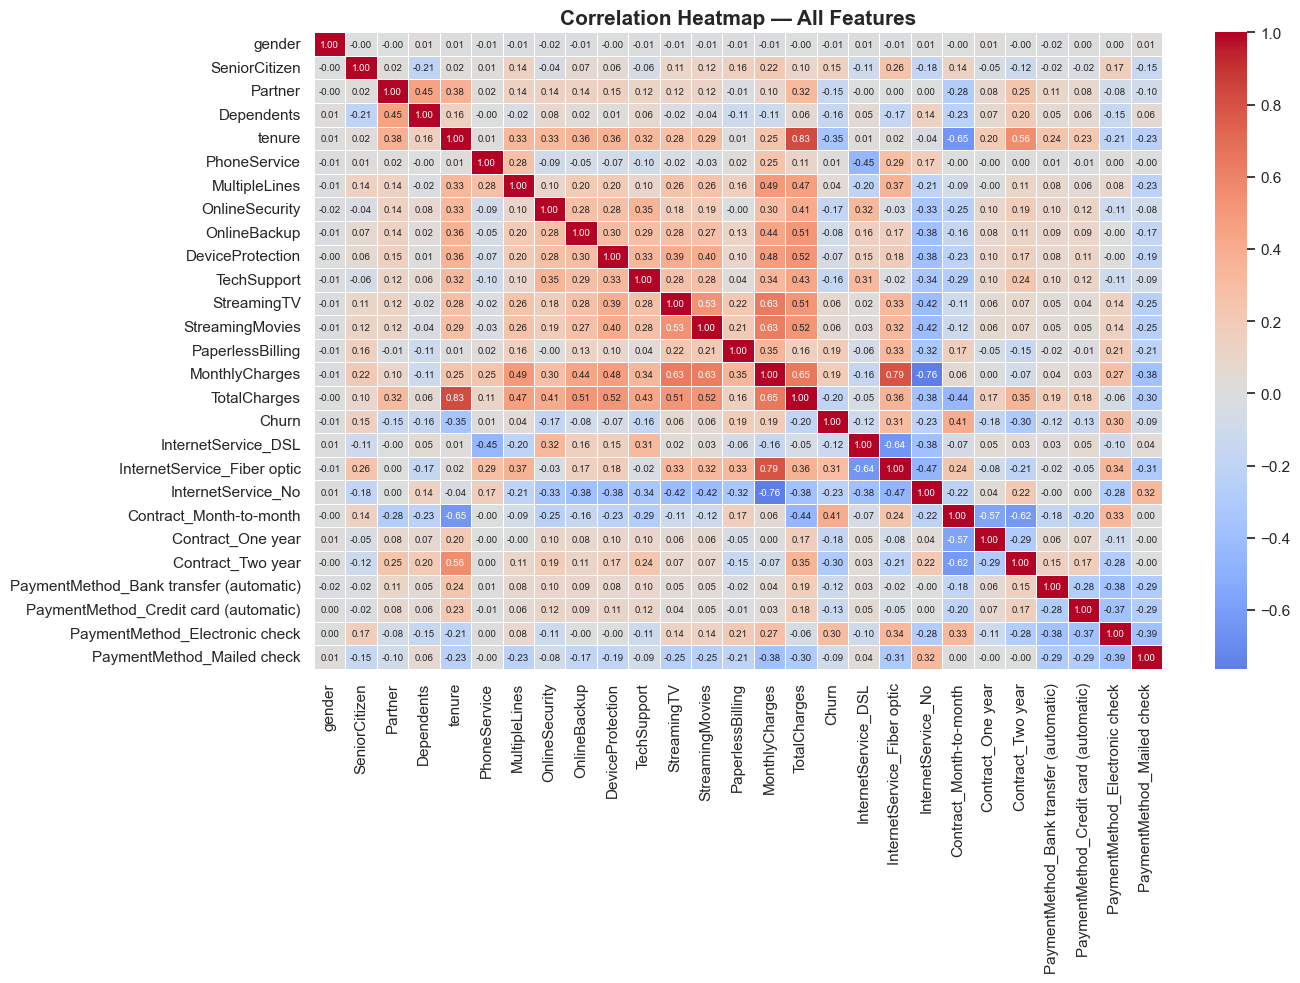

Correlation with Churn (ranked):
Churn                                      1.00
Contract_Month-to-month                    0.41
InternetService_Fiber optic                0.31
PaymentMethod_Electronic check             0.30
MonthlyCharges                             0.19
PaperlessBilling                           0.19
SeniorCitizen                              0.15
StreamingTV                                0.06
StreamingMovies                            0.06
MultipleLines                              0.04
PhoneService                               0.01
gender                                    -0.01
DeviceProtection                          -0.07
OnlineBackup                              -0.08
PaymentMethod_Mailed check                -0.09
PaymentMethod_Bank transfer (automatic)   -0.12
InternetService_DSL                       -0.12
PaymentMethod_Credit card (automatic)     -0.13
Partner                                   -0.15
Dependents                                -0.16
TechSup

In [87]:
# Correlation Heatmap

# Drop the temporary columns we created for plotting
df_corr = Churn_df.drop(columns=['Contract_Type',
                            'Internet_Type'], errors='ignore')

plt.figure(figsize=(14, 10))
corr_matrix = df_corr.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Correlation Heatmap — All Features',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print just the Churn correlations ranked
print("Correlation with Churn (ranked):")
print(corr_matrix['Churn'].sort_values(ascending=False).round(2))

# From the Statistics, Tenure has a strong correlation but not to our Target variable, for the target variable which is churn, Contract_Month_by_month has the highest relationship which may implies that custumers that are on month to month contract could have high churn rate.

## PHASE 4 - FEATURE ENGINEERING AND PREPARING FOR MODELLING

In [88]:
# Vertical Split
# Separate Features (X) and Target (y)

# Drop temporary plotting columns and target to get X
# Feature Matrix
X = Churn_df.drop(columns=['Churn',
                      'Contract_Type',
                      'Internet_Type'], errors='ignore')

# Target variable
y = Churn_df['Churn']

print(f"✅ Features shape (X): {X.shape}")
print(f"✅ Target shape   (y): {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for col in X.columns:
    print(f"   → {col}")
print(f"\nTarget distribution:")
print(y.value_counts())

✅ Features shape (X): (7043, 26)
✅ Target shape   (y): (7043,)

Feature columns (26):
   → gender
   → SeniorCitizen
   → Partner
   → Dependents
   → tenure
   → PhoneService
   → MultipleLines
   → OnlineSecurity
   → OnlineBackup
   → DeviceProtection
   → TechSupport
   → StreamingTV
   → StreamingMovies
   → PaperlessBilling
   → MonthlyCharges
   → TotalCharges
   → InternetService_DSL
   → InternetService_Fiber optic
   → InternetService_No
   → Contract_Month-to-month
   → Contract_One year
   → Contract_Two year
   → PaymentMethod_Bank transfer (automatic)
   → PaymentMethod_Credit card (automatic)
   → PaymentMethod_Electronic check
   → PaymentMethod_Mailed check

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [89]:
# Horizontal Split
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size =0.2, random_state=42, stratify=y)

print(f"Split complete!")
print(f"\nTraining set : {X_train.shape[0]} customers (80%)")
print(f"Test set     : {X_test.shape[0]} customers (20%)")
print(f"\nChurn rate in training set: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test set    : {y_test.mean()*100:.1f}%")


Split complete!

Training set : 5634 customers (80%)
Test set     : 1409 customers (20%)

Churn rate in training set: 26.5%
Churn rate in test set    : 26.5%


In [90]:
# STANDARDSCALER
# Scale Numeric Columns

scaler = StandardScaler()

#Columns to scale
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(X_train[numeric_cols].describe().round(2))

       tenure  MonthlyCharges  TotalCharges
count 5634.00         5634.00       5634.00
mean    -0.00           -0.00          0.00
std      1.00            1.00          1.00
min     -1.32           -1.54         -1.01
25%     -0.96           -0.97         -0.83
50%     -0.14            0.18         -0.40
75%      0.92            0.83          0.67
max      1.61            1.79          2.80


In [91]:
# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)

x_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("SMOTE Applied")
print(f"\nBefore SMOTE:")
print(f"   No Churn : {sum(y_train == 0):,}")
print(f"   Churn : {sum(y_train == 1):,}")

print(f"\nAfter SMOTE:")
print(f"   No Churn : {sum(y_train_sm == 0):,}")
print(f"   Churn: {sum(y_train_sm == 1):,}")

print(f"\nNew Training Set Size: {x_train_sm.shape[0]:,} customers")


SMOTE Applied

Before SMOTE:
   No Churn : 4,139
   Churn : 1,495

After SMOTE:
   No Churn : 4,139
   Churn: 4,139

New Training Set Size: 8,278 customers


## PHASE 5 - MACHINE LEARNING MODEL

In [92]:
# Model 1 - LOGISTIC REGRESSION

# Build and train model
Ir_model = LogisticRegression(random_state=42, max_iter=1000)

Ir_model.fit(x_train_sm, y_train_sm)

# Make predictions on test set
Ir_preds = Ir_model.predict(X_test)
Ir_proba = Ir_model.predict_proba(X_test)[:, 1]

In [93]:
# EVALUATION
print("=" * 50)
print("     MODEL 1 - LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(classification_report(y_test, Ir_preds,
                            target_names = ['No Churn', 'Churn']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, Ir_proba):.4f}")

     MODEL 1 - LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC Score: 0.8356


# Baseline for Logistic Regression
The Recall for churn is 0.72
The ROC-AUC IS 0.84


In [94]:
# Model 2 RANDOM FOREST

# Build and train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_sm, y_train_sm)

# Make prediction on test set
rf_preds =rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:,1]

In [95]:
# EVALUATION
print("=" * 50)
print("     MODEL 2 - RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, rf_preds,
                            target_names = ['No Churn', 'Churn']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_proba):.4f}")

     MODEL 2 - RANDOM FOREST RESULTS
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC Score: 0.8222


# Baseline for Randomforest
ROC-AUC Score for churn = 0.8222
recall for churn = 0.64



In [96]:
# Model 3 - XGBOOST - Extreme Gradient boosting
# Build and train the model
xgb_model = XGBClassifier(n_estimators=100,
                          random_state=42,
                          eval_metric='logloss',
                          verbosity=0)
xgb_model.fit(x_train_sm, y_train_sm)

# make prediction on our test set
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:,1] 


In [97]:
# EVALUATION
print("=" * 50)
print("     MODEL 3 - XGBOOST RESULTS")
print("=" * 50)
print(classification_report(y_test, xgb_preds,
                            target_names = ['No Churn', 'Churn']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_proba):.4f}")

     MODEL 3 - XGBOOST RESULTS
              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.84      1035
       Churn       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409

ROC-AUC Score: 0.8076


# Baseline for XGBOOST
ROC-AUC Score for churn = 0.81
Recall for churn = 0.66


# General findings for the three (3) models, Logistic Regression has proved to be the best model with the value of ROC-AUC - 0.84 and Recall - 0.72 as compared with Random Forest and XGBOOST, which ascertains that, the complexity of a model doesn't guarantee the model will do better.

In [98]:
# fixing the drop_first = False
# dropping model : drop one dummy per one-hot group to remove multicollinearity
redundant_dummies = ['InternetService_No', 'Contract_Month-to-month', 'PaymentMethod_Mailed check']
model_df = Churn_df.drop(columns=[c for c in redundant_dummies if c in Churn_df.columns], errors='ignore')
model_df = model_df.drop(columns=['Contract_Type', 'Internet_Type'], errors='ignore')  # EDA helper columns

print("Modeling columns:", model_df.shape[1])


Modeling columns: 24


# The drop_first = false in phase 2 kept every dummy column which creates multicollinearity (two or more independent features highly correlated linearly, in this case, 'internet service', contract month to month and payment method). These were removed by creating a model_df to drop the redundant dummies which could affect our model.

In [99]:
# Adding Average Monthly spend, bucket tenure and contract by internet service
model_df['AvgMonthlySpend'] = model_df['TotalCharges'] / (model_df['tenure'] + 1)

model_df['TenureBucket'] = pd.cut(
    model_df['tenure'],
    bins=[-1, 12, 24, 48, 100],
    labels=['0-12', '12-24', '24-48', '48+']
)
model_df = pd.get_dummies(model_df, columns=['TenureBucket'], drop_first=True)

model_df['Fiber_x_MonthToMonth'] = (
    (model_df['InternetService_Fiber optic'] == 1) &
    (model_df.get('Contract_One year', 0) == 0) &
    (model_df.get('Contract_Two year', 0) == 0)
).astype(int)

print("Shape after feature engineering:", model_df.shape)


Shape after feature engineering: (7043, 29)


# Bucket tenure was added since the boxplot reveals that Tenure is highly predictive but non-linear and there different categoris of Tenure. The shape after feature engineering shows that we have 7043 rows and 29 columns as against the 21 columns we have before feature engineering

In [100]:
# rebuild X/y and the train / test split from model_df
X = model_df.drop(columns=['Churn'])
y = model_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [101]:
# Class weighting as an alternative to SMOTE + StratifiedFold 
from sklearn.model_selection import StratifiedKFold

# Stratified CV so reported scores aren't dependent on one lucky/unlucky split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scale_pos_weight for XGBoost / class_weight='balanced' for RF,
# tested here as an alternative to SMOTE (SMOTE can distort boundaries for tree models)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.3f}")


scale_pos_weight = 2.769


In [102]:
# Tuning Random Forest with class_weight='balanced'  
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [8, 12, None],
    'min_samples_leaf': [1, 3, 5],
    'class_weight': ['balanced']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, scoring='roc_auc', cv=cv, n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Best RF params:", rf_grid.best_params_)
print(f"Best RF CV ROC-AUC: {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_
rf_proba = best_rf.predict_proba(X_test)[:, 1]
rf_preds = best_rf.predict(X_test)

print(classification_report(y_test, rf_preds, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

Best RF params: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 400}
Best RF CV ROC-AUC: 0.8477
              precision    recall  f1-score   support

    No Churn       0.91      0.77      0.83      1035
       Churn       0.55      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409

ROC-AUC: 0.8457


# After tuning Random Forest with Class_weight = balanced, the Recall for Churn has a significant change of 0.78 while the ROC-AUC is 0.85

In [103]:
#Tuning XGBoost with Scale_pos_weight

xgb_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [1, 3],
    'scale_pos_weight': [scale_pos_weight]}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    xgb_param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)

xgb_grid.fit(X_train, y_train)
print("Best XGB params:", xgb_grid.best_params_)
print(f"Best XGB CV ROC-AUC: {xgb_grid.best_score_:.4f}")

best_xgb = xgb_grid.best_estimator_
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]
xgb_preds = best_xgb.predict(X_test)

print(classification_report(y_test, xgb_preds, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")


Best XGB params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'scale_pos_weight': np.float64(2.768561872909699)}
Best XGB CV ROC-AUC: 0.8466
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409

ROC-AUC: 0.8433


# Baseline - After Tuning Random Forest, ROC-AUC increased to 0.85 as against 0.82 and Recall increased to 0.78 as against  0.64 before tuning.
After Tuning XGBoost, ROC-AUC increased to 0.84 as against 0.81 and Recall increased to 0.79 as against 0.66 before tuning. 

## PHASE 6 - MODEL EVALUATION AND VISUALIZATION

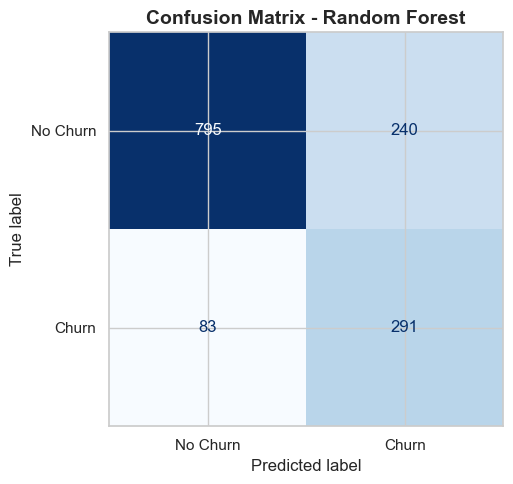

True  Negatives (correctly said stay) : 795
False Positives (wrongly said churn) : 240
False Negatives (missed churners) : 83
True  Positives (correctly caught) : 291


In [104]:

# CONFUSION MATRIX - RANDOM FOREST
cm = confusion_matrix(y_test, rf_preds)
fig, ax = plt.subplots(figsize=(7,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Break down the numbers
tn,fp,fn,tp = cm.ravel()
print(f"True  Negatives (correctly said stay) : {tn}")
print(f"False Positives (wrongly said churn) : {fp}")
print(f"False Negatives (missed churners) : {fn}")
print(f"True  Positives (correctly caught) : {tp}")


True Negatives is 795
False Positives is 240
False Negatives is 83
True Positive is 291

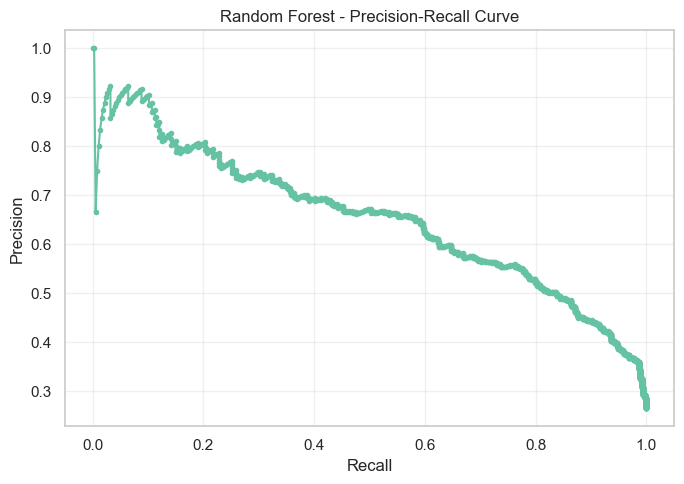

In [105]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest - Precision-Recall Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


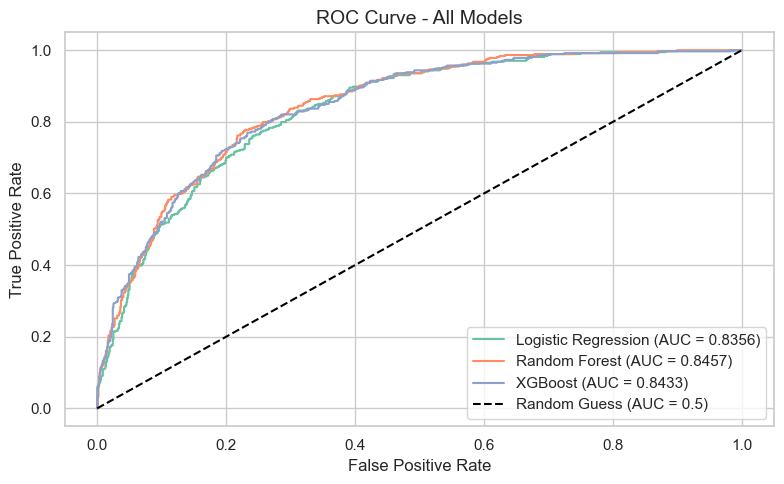

AUC Scores:
  Logistic Regression : 0.8356
  Random Forest   : 0.8457
  XGBoost   : 0.8433


In [106]:
#ROC-Curve All 3 models
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,5))

# plot all 3 models
for name, proba in [('Logistic Regression', Ir_proba),
                    ('Random Forest', rf_proba),
                    ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

 # Random guess baseline
plt.plot([0,1], [0,1], 'k--', label='Random Guess (AUC = 0.5)')

plt.title('ROC Curve - All Models', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

#AUC Scores
print("AUC Scores:")
print(f"  Logistic Regression : {roc_auc_score(y_test, Ir_proba):.4f}")
print(f"  Random Forest   : {roc_auc_score(y_test, rf_proba):.4f}")
print(f"  XGBoost   : {roc_auc_score(y_test, xgb_proba):.4f}")

Random Forest has the highest value when compared with others.

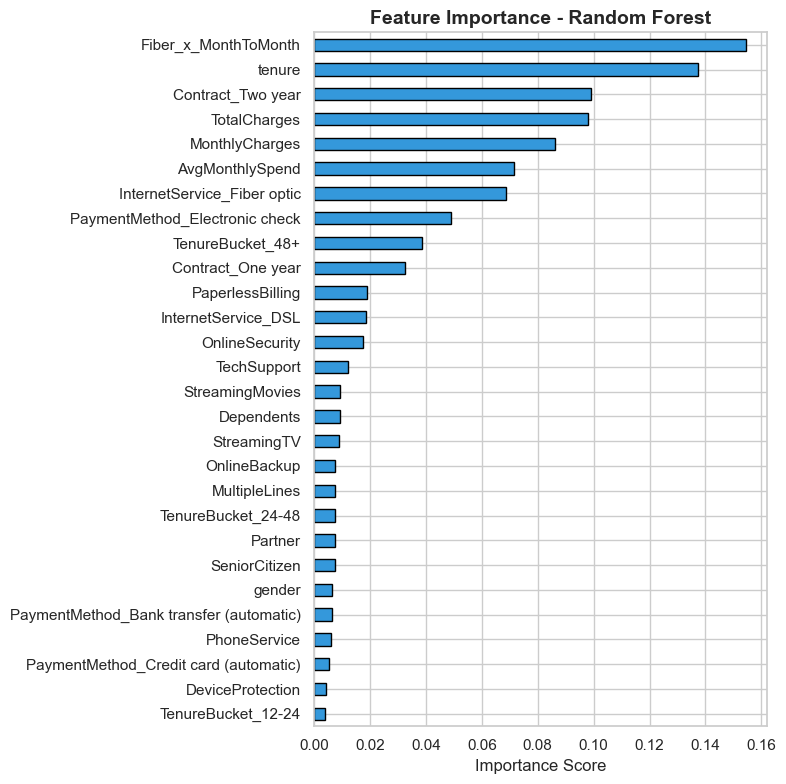

Top 5 Most important Features:
Fiber_x_MonthToMonth   0.15
tenure                 0.14
Contract_Two year      0.10
TotalCharges           0.10
MonthlyCharges         0.09
dtype: float64


In [109]:
# Feature Importance - Random Forest (for clean built-in importance score)

importances = pd.Series(best_rf.feature_importances_,
                       index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8,8))
importances.plot(kind='barh', color= '#3498db', 
                 edgecolor='black')

plt.title('Feature Importance - Random Forest',
         fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 Most important Features:")
print(importances.sort_values(ascending=False).head())


 Final Scores Table:
                     Accuracy  Recall  Precision  F1 Score  ROC-AUC
Logistic Regression      0.76    0.72       0.54      0.62     0.84
Random Forest            0.77    0.78       0.55      0.64     0.85
XGBoost                  0.75    0.79       0.52      0.63     0.84


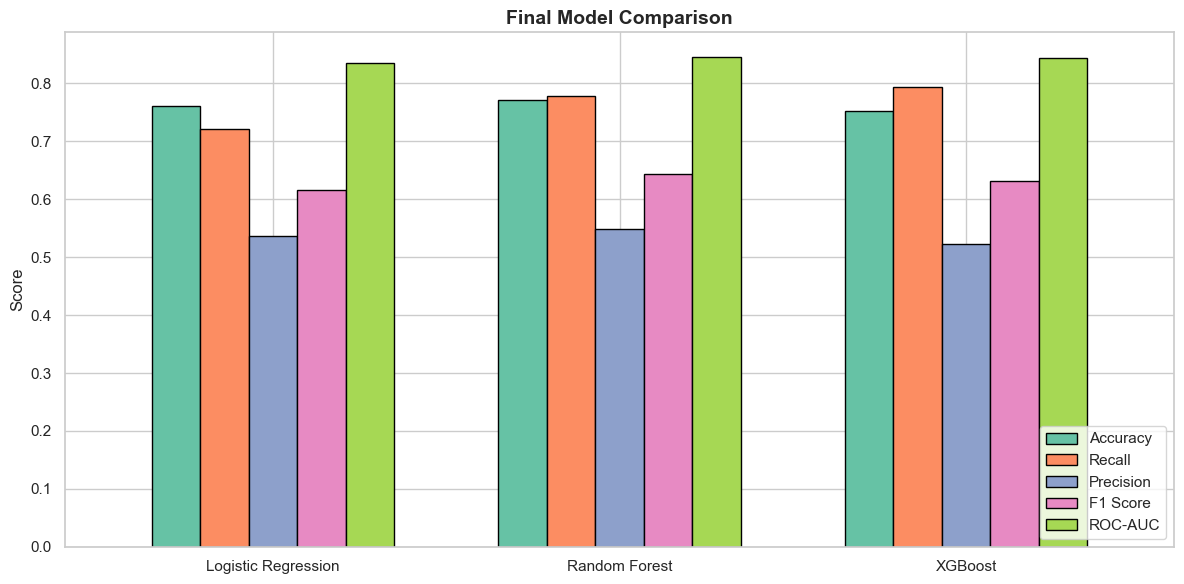

In [111]:
# Final Model Comparison

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

#collect all scores
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
metrics = { 'Accuracy' : [accuracy_score(y_test, Ir_preds),
                          accuracy_score(y_test, rf_preds),
                          accuracy_score(y_test, xgb_preds)],
           'Recall'    : [recall_score(y_test, Ir_preds),
                          recall_score(y_test, rf_preds),
                          recall_score(y_test, xgb_preds)],
           'Precision' : [precision_score(y_test, Ir_preds),
                          precision_score(y_test, rf_preds),
                          precision_score(y_test, xgb_preds)],
           'F1 Score'  : [f1_score(y_test, Ir_preds),
                          f1_score(y_test, rf_preds),
                          f1_score(y_test, xgb_preds)],
           'ROC-AUC'   : [roc_auc_score(y_test, Ir_proba),
                          roc_auc_score(y_test, rf_proba),
                          roc_auc_score(y_test, xgb_proba)]}

results_df =pd.DataFrame(metrics, index=models)

#plot
results_df.plot(kind='bar', figsize=(12,6),
                edgecolor='black', width=0.7)
plt.title('Final Model Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()

print("\n Final Scores Table:")
print(results_df.round(4))


In [ ]:
# Save Model
import joblib
